In [63]:
# ============================================================================
# IMPORTS
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
# Model selection and feature selection
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.base import clone
from xgboost import XGBClassifier, XGBRegressor

In [64]:
# ============================================================================
# 1. LOAD DATA
# ============================================================================

# Load scaled and unscaled feature sets (sorted by video_id)
x_train_scaled = pd.read_csv("integrated_features/data/x_train_scaled.csv").sort_values("video_id")
x_test_scaled = pd.read_csv("integrated_features/data/x_test_scaled.csv").sort_values("video_id")

x_train_unscaled = pd.read_csv("integrated_features/data/x_train_unscaled.csv").sort_values("video_id")
x_test_unscaled = pd.read_csv("integrated_features/data/x_test_unscaled.csv").sort_values("video_id")

# Load labels (continuous scores)
y_train = pd.read_csv("integrated_features/data/train_y.csv").sort_values("video_id")
y_test = pd.read_csv("integrated_features/data/test_y.csv").sort_values("video_id")

print("Shapes:")
print(f"x_train_scaled: {x_train_scaled.shape}")
print(f"x_test_scaled:  {x_test_scaled.shape}")
print(f"y_train:        {y_train.shape}")
print(f"y_test:         {y_test.shape}")

Shapes:
x_train_scaled: (133, 32)
x_test_scaled:  (49, 32)
y_train:        (140, 2)
y_test:         (49, 2)


In [65]:
# ============================================================================
# 2. PREPARE LABELS: CONTINUOUS SCORE + BINARY LABELS
# ============================================================================

# Identify score column (the second column if video_id exists)
label_col = y_train.columns[1] if "video_id" in y_train.columns else y_train.columns[0]

# Extract continuous scores
y_train_score = y_train[label_col].values
y_test_score = y_test[label_col].values

# Binary labels using threshold = 0.8
threshold = 0.8
y_train_binary = (y_train_score >= threshold).astype(int)
y_test_binary = (y_test_score >= threshold).astype(int)

print("\nLabel column:", label_col)
print(f"Train score range: {y_train_score.min():.3f} - {y_train_score.max():.3f}")
print(f"Test score range:  {y_test_score.min():.3f} - {y_test_score.max():.3f}")

print("\nBinary label distribution:")
print("Train:", pd.Series(y_train_binary).value_counts().sort_index())
print("Test:", pd.Series(y_test_binary).value_counts().sort_index())



Label column: label
Train score range: 0.444 - 1.000
Test score range:  0.422 - 1.000

Binary label distribution:
Train: 0    57
1    83
Name: count, dtype: int64
Test: 0    20
1    29
Name: count, dtype: int64


In [66]:
# ============================================================================
# 3. ALIGN DATA BY video_id
# ============================================================================

print("\nAligning data by video_id...")

# Determine common video_ids between feature and label sets
train_ids_x = set(x_train_scaled["video_id"].unique())
test_ids_x = set(x_test_scaled["video_id"].unique())
train_ids_y = set(y_train["video_id"].unique())
test_ids_y = set(y_test["video_id"].unique())

train_common = sorted(list(train_ids_x & train_ids_y))
test_common = sorted(list(test_ids_x & test_ids_y))

print(f"Common train video_ids: {len(train_common)}")
print(f"Common test video_ids:  {len(test_common)}")

# Filter and align by video_id
x_train_aligned = (
    x_train_scaled[x_train_scaled["video_id"].isin(train_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)

x_test_aligned = (
    x_test_scaled[x_test_scaled["video_id"].isin(test_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)

y_train_aligned = (
    y_train[y_train["video_id"].isin(train_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)

y_test_aligned = (
    y_test[y_test["video_id"].isin(test_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)

# Build feature matrices
X_train = x_train_aligned.drop(columns=["video_id"]).values
X_test = x_test_aligned.drop(columns=["video_id"]).values
feature_names = x_train_aligned.drop(columns=["video_id"]).columns.tolist()

# Aligned labels
y_train_score_aligned = y_train_aligned[label_col].values
y_test_score_aligned = y_test_aligned[label_col].values

# Align binary labels
y_train_binary_aligned = (
    pd.DataFrame({"video_id": y_train["video_id"], "label": y_train_binary})
    .loc[lambda df: df["video_id"].isin(train_common)]
    .sort_values("video_id")["label"]
    .values
)

y_test_binary_aligned = (
    pd.DataFrame({"video_id": y_test["video_id"], "label": y_test_binary})
    .loc[lambda df: df["video_id"].isin(test_common)]
    .sort_values("video_id")["label"]
    .values
)

print("\nVerification:")
print("X_train:", X_train.shape)
print("y_train_score_aligned:", y_train_score_aligned.shape)
print("y_train_binary_aligned:", y_train_binary_aligned.shape)

print("X_test:", X_test.shape)
print("y_test_score_aligned:", y_test_score_aligned.shape)
print("y_test_binary_aligned:", y_test_binary_aligned.shape)


Aligning data by video_id...
Common train video_ids: 133
Common test video_ids:  48

Verification:
X_train: (133, 31)
y_train_score_aligned: (133,)
y_train_binary_aligned: (133,)
X_test: (48, 31)
y_test_score_aligned: (48,)
y_test_binary_aligned: (48,)


## Ridge Regression

In [52]:
def run_regression_with_threshold(
    model,
    model_name,
    X_train,
    y_train_score,
    y_train_bin,
    X_test,
    y_test_score,
    y_test_bin,
    thr_min=0.3,
    thr_max=0.9,
    thr_step=0.01,
    n_splits=5,
    random_state=42,
    plot=True,
):
    """
    Full pipeline:
    1. Train regression model using cross-val and generate OOF predictions.
    2. Search best threshold on OOF predictions for binary classification.
    3. Train final model on full training data.
    4. Evaluate on both train and test sets using tuned threshold.
    5. (Optional) Visualize:
       - ROC curves (train OOF vs test)
       - Threshold vs metrics curves (accuracy, precision, recall, F1 on train OOF)
    """
    print("\n" + "=" * 80)
    print(f"MODEL: {model_name}")
    print("=" * 80)

    # ----------------------------------------------------------------------
    # STEP 1: Generate Out-of-Fold (OOF) predictions
    # ----------------------------------------------------------------------
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_scores = np.zeros_like(y_train_score, dtype=float)

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train_bin), 1):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr = y_train_score[tr_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        oof_scores[val_idx] = m.predict(X_val)

        print(f"  Fold {fold_idx} completed.")

    # ----------------------------------------------------------------------
    # STEP 2: Search best threshold on OOF predictions
    # ----------------------------------------------------------------------
    thresholds = np.arange(thr_min, thr_max + thr_step, thr_step)

    # Store metrics for each threshold for visualization
    acc_list = []
    prec_list = []
    rec_list = []
    f1_list = []

    best_thr = None
    best_acc = -1
    best_f1 = -1

    for thr in thresholds:
        preds = (oof_scores >= thr).astype(int)
        acc = accuracy_score(y_train_bin, preds)
        prec = precision_score(y_train_bin, preds, zero_division=0)
        rec = recall_score(y_train_bin, preds, zero_division=0)
        f1 = f1_score(y_train_bin, preds, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)

        # Use accuracy as primary metric, F1 as tie-breaker
        if acc > best_acc or (np.isclose(acc, best_acc) and f1 > best_f1):
            best_thr = thr
            best_acc = acc
            best_f1 = f1

    print("\nBest threshold found:")
    print(f"  threshold = {best_thr:.3f}")
    print(f"  CV accuracy = {best_acc:.4f}")
    print(f"  CV F1       = {best_f1:.4f}")

    # ----------------------------------------------------------------------
    # STEP 3: Fit final regression model on full training set
    # ----------------------------------------------------------------------
    final_model = clone(model)
    final_model.fit(X_train, y_train_score)

    # Predictions on full train and test
    train_score_pred = final_model.predict(X_train)
    test_score_pred = final_model.predict(X_test)

    # Convert to binary labels using tuned threshold
    train_bin_pred = (train_score_pred >= best_thr).astype(int)
    test_bin_pred = (test_score_pred >= best_thr).astype(int)

    # ----------------------------------------------------------------------
    # STEP 4: Compute metrics on train and test
    # ----------------------------------------------------------------------
    def report(split_name, y_true_bin, score_pred, bin_pred):
        acc = accuracy_score(y_true_bin, bin_pred)
        prec = precision_score(y_true_bin, bin_pred, zero_division=0)
        rec = recall_score(y_true_bin, bin_pred, zero_division=0)
        f1 = f1_score(y_true_bin, bin_pred, zero_division=0)
        auc_val = roc_auc_score(y_true_bin, score_pred)

        print(f"\n{split_name} Performance (threshold = {best_thr:.3f}):")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1:        {f1:.4f}")
        print(f"  AUC:       {auc_val:.4f}")

        return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc_val)

    train_metrics = report("Train", y_train_bin, train_score_pred, train_bin_pred)
    test_metrics = report("Test", y_test_bin, test_score_pred, test_bin_pred)

    # ----------------------------------------------------------------------
    # STEP 5: Visualization (ROC + threshold vs metrics)
    # ----------------------------------------------------------------------
    if plot:
        # ------------------- 5.1 ROC curves -------------------
        # Train ROC uses OOF scores to avoid target leakage
        fpr_train, tpr_train, _ = roc_curve(y_train_bin, oof_scores)
        roc_auc_train = auc(fpr_train, tpr_train)

        # Test ROC uses final model predictions on test
        fpr_test, tpr_test, _ = roc_curve(y_test_bin, test_score_pred)
        roc_auc_test = auc(fpr_test, tpr_test)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr_train, tpr_train, label=f"Train (OOF) ROC (AUC = {roc_auc_train:.3f})")
        plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {roc_auc_test:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curves - {model_name}")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # ------------------- 5.2 Threshold vs metrics ---------
        plt.figure(figsize=(7, 5))
        plt.plot(thresholds, acc_list, label="Accuracy")
        plt.plot(thresholds, prec_list, label="Precision")
        plt.plot(thresholds, rec_list, label="Recall")
        plt.plot(thresholds, f1_list, label="F1")

        # Mark the best threshold with a vertical line
        plt.axvline(best_thr, linestyle="--", label=f"Best threshold = {best_thr:.2f}")

        plt.xlabel("Threshold on regression output")
        plt.ylabel("Score")
        plt.title(f"Threshold vs Metrics (Train OOF) - {model_name}")
        plt.legend(loc="best")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return dict(
        model=final_model,
        best_threshold=best_thr,
        train_metrics=train_metrics,
        test_metrics=test_metrics,
        train_score_pred=train_score_pred,
        test_score_pred=test_score_pred,
        oof_scores=oof_scores,
        thresholds=thresholds,
        threshold_metrics=dict(
            accuracy=np.array(acc_list),
            precision=np.array(prec_list),
            recall=np.array(rec_list),
            f1=np.array(f1_list),
        ),
    )


MODEL: Ridge Regression
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.

Best threshold found:
  threshold = 0.750
  CV accuracy = 0.6241
  CV F1       = 0.7396

Train Performance (threshold = 0.750):
  Accuracy:  0.6316
  Precision: 0.6311
  Recall:    0.9506
  F1:        0.7586
  AUC:       0.7424

Test Performance (threshold = 0.750):
  Accuracy:  0.5208
  Precision: 0.5750
  Recall:    0.7931
  F1:        0.6667
  AUC:       0.4828


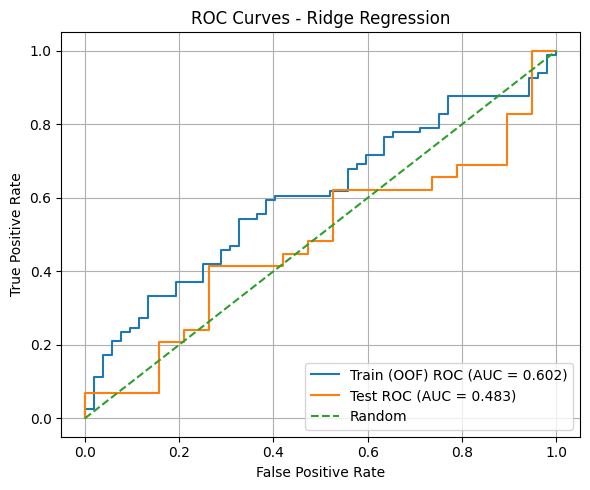

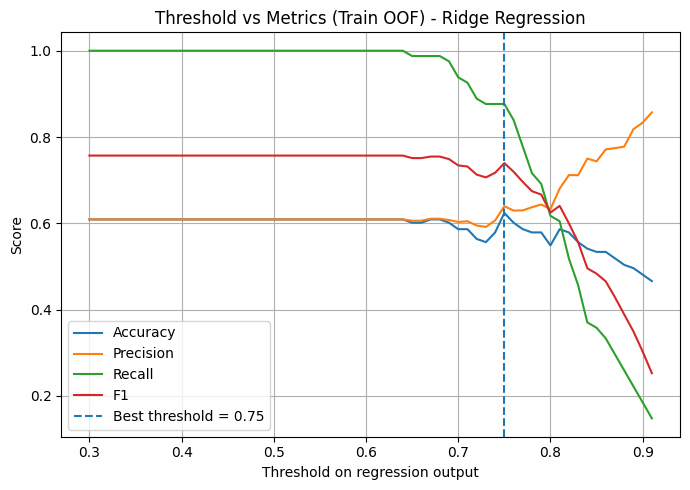


Ridge Regression completed.
Best threshold: 0.7500000000000004
Test metrics: {'accuracy': 0.5208333333333334, 'precision': 0.575, 'recall': 0.7931034482758621, 'f1': 0.6666666666666666, 'auc': np.float64(0.4827586206896552)}


In [53]:
# ============================================================================
# 5. RUN RIDGE REGRESSION
# ============================================================================

ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_results = run_regression_with_threshold(
    model=ridge_model,
    model_name="Ridge Regression",
    X_train=X_train,
    y_train_score=y_train_score_aligned,
    y_train_bin=y_train_binary_aligned,
    X_test=X_test,
    y_test_score=y_test_score_aligned,
    y_test_bin=y_test_binary_aligned,
)

print("\nRidge Regression completed.")
print("Best threshold:", ridge_results["best_threshold"])
print("Test metrics:", ridge_results["test_metrics"])


## Reandom Forest


MODEL: RandomForest Regressor
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.

Best threshold found:
  threshold = 0.300
  CV accuracy = 0.6090
  CV F1       = 0.7570

Train Performance (threshold = 0.300):
  Accuracy:  0.6090
  Precision: 0.6090
  Recall:    1.0000
  F1:        0.7570
  AUC:       0.9934

Test Performance (threshold = 0.300):
  Accuracy:  0.6042
  Precision: 0.6042
  Recall:    1.0000
  F1:        0.7532
  AUC:       0.5608


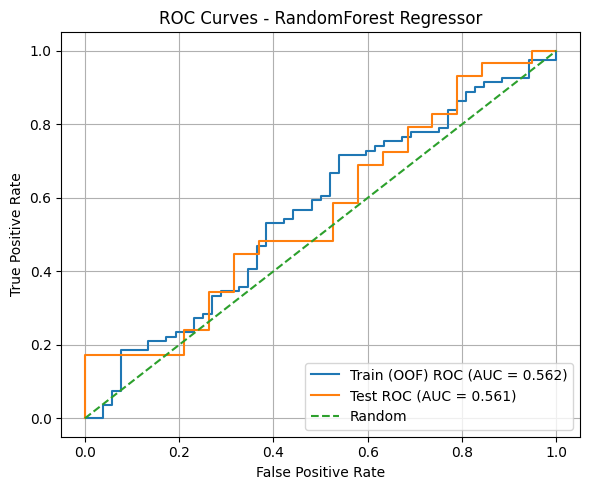

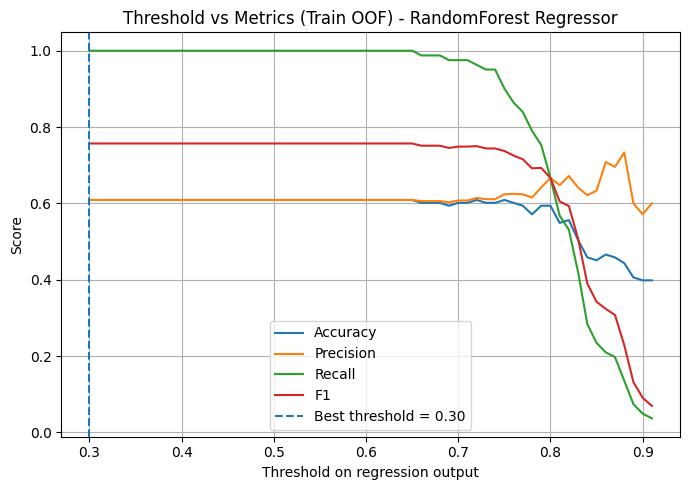


RandomForest completed.
Best threshold: 0.3
Test metrics: {'accuracy': 0.6041666666666666, 'precision': 0.6041666666666666, 'recall': 1.0, 'f1': 0.7532467532467533, 'auc': np.float64(0.5607985480943739)}


In [56]:
rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
)

rf_results = run_regression_with_threshold(
    model=rf_reg,
    model_name="RandomForest Regressor",
    X_train=X_train,
    y_train_score=y_train_score_aligned,
    y_train_bin=y_train_binary_aligned,
    X_test=X_test,
    y_test_score=y_test_score_aligned,
    y_test_bin=y_test_binary_aligned,
)

print("\nRandomForest completed.")
print("Best threshold:", rf_results["best_threshold"])
print("Test metrics:", rf_results["test_metrics"])


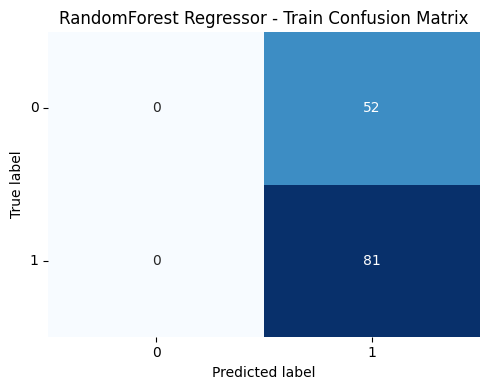

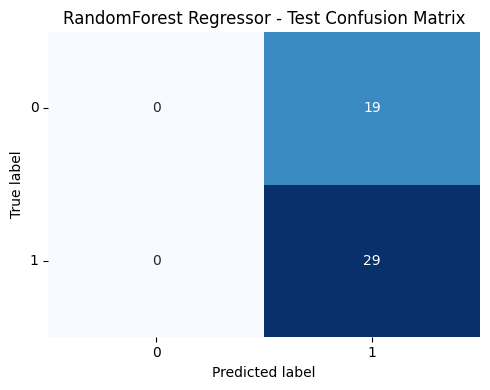

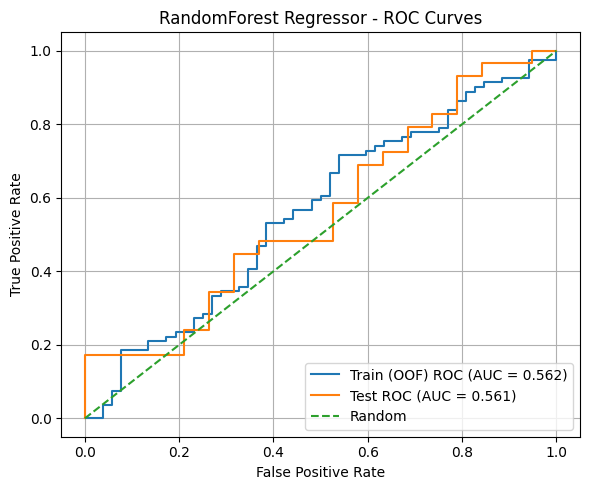

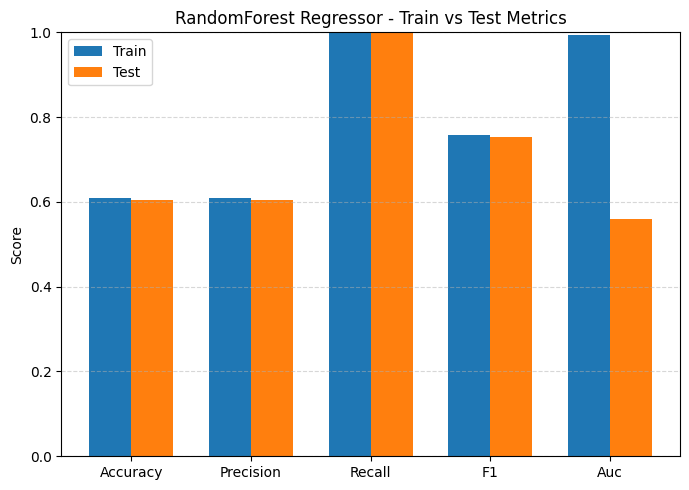

In [70]:
# Best threshold selected on train OOF predictions
best_thr = rf_results["best_threshold"]

# Continuous predictions on full train and test from the final RF model
train_scores = rf_results["train_score_pred"]
test_scores = rf_results["test_score_pred"]

# Binary predictions using the tuned threshold
train_pred = (train_scores >= best_thr).astype(int)
test_pred = (test_scores >= best_thr).astype(int)

# ---------------------------------------------------------------------------
# 7.2 Confusion matrices (Train and Test)
# ---------------------------------------------------------------------------

# Compute confusion matrices
cm_train = confusion_matrix(y_train_binary_aligned, train_pred)
cm_test = confusion_matrix(y_test_binary_aligned, test_pred)

# Plot train confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("RandomForest Regressor - Train Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0.5, 1.5], ["0", "1"])
plt.yticks([0.5, 1.5], ["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

# Plot test confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("RandomForest Regressor - Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0.5, 1.5], ["0", "1"])
plt.yticks([0.5, 1.5], ["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 7.3 ROC curves (Train and Test)
# ---------------------------------------------------------------------------
# If you used the updated run_regression_with_threshold, you also have OOF
# scores in rf_results["oof_scores"]. Here we plot ROC using:
#   - Train: OOF scores (preferred, no leakage)
#   - Test: final model predictions on the test set

oof_scores = rf_results["oof_scores"]

# Train ROC using OOF scores
fpr_train, tpr_train, _ = roc_curve(y_train_binary_aligned, oof_scores)
roc_auc_train = auc(fpr_train, tpr_train)

# Test ROC using final model predictions
fpr_test, tpr_test, _ = roc_curve(y_test_binary_aligned, test_scores)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr_train, tpr_train, label=f"Train (OOF) ROC (AUC = {roc_auc_train:.3f})")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {roc_auc_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RandomForest Regressor - ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 7.4 Bar chart: train vs test metrics comparison
# ---------------------------------------------------------------------------

# Extract metrics from rf_results
train_metrics = rf_results["train_metrics"]
test_metrics = rf_results["test_metrics"]

metric_names = ["accuracy", "precision", "recall", "f1", "auc"]
train_values = [train_metrics[m] for m in metric_names]
test_values = [test_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))  # metric indices
width = 0.35                      # bar width

plt.figure(figsize=(7, 5))
plt.bar(x - width / 2, train_values, width, label="Train")
plt.bar(x + width / 2, test_values, width, label="Test")

plt.xticks(x, [m.capitalize() for m in metric_names])
plt.ylim(0.0, 1.0)
plt.ylabel("Score")
plt.title("RandomForest Regressor - Train vs Test Metrics")
plt.legend(loc="best")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## XGBoostRegressor

In [71]:
# ============================================================================
# 2. DEFINE SCORE → 3-CLASS MAPPING
# ============================================================================

# Identify the score column name
label_col = y_train.columns[1] if "video_id" in y_train.columns else y_train.columns[0]

# Define thresholds for 3-class labeling
low_thr = 0.65
high_thr = 0.80

def score_to_3class(score, low=low_thr, high=high_thr):
    """
    Map continuous score to 3 ordinal classes:
      0: Low    (score < low)
      1: Medium (low <= score < high)
      2: High   (score >= high)
    """
    if score < low:
        return 0
    elif score < high:
        return 1
    else:
        return 2

# Quick view of raw score ranges
print("\nRaw score ranges:")
print(f"Train: {y_train[label_col].min():.3f} - {y_train[label_col].max():.3f}")
print(f"Test:  {y_test[label_col].min():.3f} - {y_test[label_col].max():.3f}")

# ============================================================================
# 3. ALIGN BY video_id
# ============================================================================

print("\nAligning data by video_id...")

train_ids_x = set(x_train_scaled["video_id"].unique())
test_ids_x = set(x_test_scaled["video_id"].unique())
train_ids_y = set(y_train["video_id"].unique())
test_ids_y = set(y_test["video_id"].unique())

train_common = sorted(list(train_ids_x & train_ids_y))
test_common = sorted(list(test_ids_x & test_ids_y))

print(f"Common train video_ids: {len(train_common)}")
print(f"Common test  video_ids: {len(test_common)}")

# Align X
x_train_aligned = (
    x_train_scaled[x_train_scaled["video_id"].isin(train_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)
x_test_aligned = (
    x_test_scaled[x_test_scaled["video_id"].isin(test_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)

# Align y
y_train_aligned = (
    y_train[y_train["video_id"].isin(train_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)
y_test_aligned = (
    y_test[y_test["video_id"].isin(test_common)]
    .sort_values("video_id")
    .reset_index(drop=True)
)

# Feature matrices
X_train = x_train_aligned.drop(columns=["video_id"]).values
X_test = x_test_aligned.drop(columns=["video_id"]).values
feature_names = x_train_aligned.drop(columns=["video_id"]).columns.tolist()

# Continuous scores (aligned)
y_train_score = y_train_aligned[label_col].values
y_test_score = y_test_aligned[label_col].values

# 3-class labels (aligned)
y_train_3class = np.array([score_to_3class(s) for s in y_train_score], dtype=int)
y_test_3class = np.array([score_to_3class(s) for s in y_test_score], dtype=int)

# Binary labels for "High vs Others"
# High: class == 2, Others: class in {0, 1}
y_train_bin_high = (y_train_3class == 2).astype(int)
y_test_bin_high = (y_test_3class == 2).astype(int)

print("\nVerification:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train_score:", y_train_score.shape)
print("y_test_score: ", y_test_score.shape)
print("y_train_3class:", np.bincount(y_train_3class))
print("y_test_3class: ", np.bincount(y_test_3class))
print("y_train_bin_high:", np.bincount(y_train_bin_high))
print("y_test_bin_high: ", np.bincount(y_test_bin_high))

# ============================================================================
# 4. HELPER: REPORT BINARY METRICS (High vs Others)
# ============================================================================

def report_binary_metrics(name, y_true_bin, score_pred, bin_pred):
    """
    Print and return binary classification metrics:
      accuracy, precision, recall, F1, AUC
    """
    acc = accuracy_score(y_true_bin, bin_pred)
    prec = precision_score(y_true_bin, bin_pred, zero_division=0)
    rec = recall_score(y_true_bin, bin_pred, zero_division=0)
    f1 = f1_score(y_true_bin, bin_pred, zero_division=0)
    auc = roc_auc_score(y_true_bin, score_pred)

    print(f"\n{name} performance (High vs Others):")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")

    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc)

# ============================================================================
# 5. METHOD A: XGBoostClassifier (3-class softmax)
# ============================================================================

print("\n" + "=" * 80)
print("METHOD A: XGBoostClassifier (3-class) + High vs Others")
print("=" * 80)

# XGBoost multi-class classifier
clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    tree_method="auto",  # adjust if GPU available
)

# Train on 3-class labels
clf.fit(X_train, y_train_3class)

# 3-class predictions
train_3class_pred = clf.predict(X_train)
test_3class_pred = clf.predict(X_test)

# 3-class accuracy (for reference)
train_3class_acc = accuracy_score(y_train_3class, train_3class_pred)
test_3class_acc = accuracy_score(y_test_3class, test_3class_pred)

print("\n3-class accuracy:")
print(f"  Train: {train_3class_acc:.4f}")
print(f"  Test:  {test_3class_acc:.4f}")

# Convert to binary High vs Others
train_bin_pred_A = (train_3class_pred == 2).astype(int)
test_bin_pred_A = (test_3class_pred == 2).astype(int)

# For AUC, we use the predicted probability of "High" (class index = 2)
train_proba = clf.predict_proba(X_train)[:, 2]
test_proba = clf.predict_proba(X_test)[:, 2]

metrics_A_train = report_binary_metrics(
    "METHOD A - Train", y_train_bin_high, train_proba, train_bin_pred_A
)
metrics_A_test = report_binary_metrics(
    "METHOD A - Test", y_test_bin_high, test_proba, test_bin_pred_A
)

# ============================================================================
# 6. METHOD B: XGBoostRegressor (ordinal target 0/1/2) + threshold search
# ============================================================================

print("\n" + "=" * 80)
print("METHOD B: XGBoostRegressor (ordinal 0/1/2) + threshold search")
print("=" * 80)

def run_ordinal_regression_with_threshold(
    model,
    X_train,
    y_train_ord,
    y_train_bin_high,
    X_test,
    y_test_ord,
    y_test_bin_high,
    thr_min=0.5,
    thr_max=2.5,
    thr_step=0.05,
    n_splits=5,
    random_state=42,
):
    """
    Use XGBoostRegressor with ordinal targets {0,1,2}.
    1. Generate out-of-fold predictions on train.
    2. Search best threshold for High vs Others based on binary labels.
    3. Fit final model and evaluate on train & test.
    """

    # Step 1: generate out-of-fold predictions
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_pred = np.zeros_like(y_train_ord, dtype=float)

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train_bin_high), 1):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr = y_train_ord[tr_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        oof_pred[val_idx] = m.predict(X_val)

        print(f"  Fold {fold_idx} completed.")

    # Step 2: threshold search on OOF predictions (High vs Others)
    thresholds = np.arange(thr_min, thr_max + thr_step, thr_step)
    best_thr = None
    best_acc = -1.0
    best_f1 = -1.0

    for thr in thresholds:
        # High if prediction >= thr, otherwise Others
        bin_pred = (oof_pred >= thr).astype(int)
        acc = accuracy_score(y_train_bin_high, bin_pred)
        f1 = f1_score(y_train_bin_high, bin_pred)

        if acc > best_acc or (np.isclose(acc, best_acc) and f1 > best_f1):
            best_thr = thr
            best_acc = acc
            best_f1 = f1

    print("\nBest threshold from CV:")
    print(f"  threshold = {best_thr:.3f}")
    print(f"  CV accuracy = {best_acc:.4f}")
    print(f"  CV F1       = {best_f1:.4f}")

    # Step 3: fit final model on full training data
    final_model = clone(model)
    final_model.fit(X_train, y_train_ord)

    train_pred_cont = final_model.predict(X_train)
    test_pred_cont = final_model.predict(X_test)

    # Binary predictions with tuned threshold
    train_bin_pred = (train_pred_cont >= best_thr).astype(int)
    test_bin_pred = (test_pred_cont >= best_thr).astype(int)

    # Binary metrics (High vs Others)
    metrics_train = report_binary_metrics(
        "METHOD B - Train", y_train_bin_high, train_pred_cont, train_bin_pred
    )
    metrics_test = report_binary_metrics(
        "METHOD B - Test", y_test_bin_high, test_pred_cont, test_bin_pred
    )

    # Optional: 3-class metrics by rounding continuous predictions
    train_3class_pred = np.clip(np.rint(train_pred_cont), 0, 2).astype(int)
    test_3class_pred = np.clip(np.rint(test_pred_cont), 0, 2).astype(int)

    train_3class_acc = accuracy_score(y_train_ord, train_3class_pred)
    test_3class_acc = accuracy_score(y_test_ord, test_3class_pred)

    print("\n3-class accuracy from ordinal regression (rounded predictions):")
    print(f"  Train: {train_3class_acc:.4f}")
    print(f"  Test:  {test_3class_acc:.4f}")

    return dict(
        model=final_model,
        best_threshold=best_thr,
        train_metrics_bin=metrics_train,
        test_metrics_bin=metrics_test,
        train_3class_acc=train_3class_acc,
        test_3class_acc=test_3class_acc,
    )

# Define XGBRegressor for ordinal regression
reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="auto",
)

results_B = run_ordinal_regression_with_threshold(
    model=reg,
    X_train=X_train,
    y_train_ord=y_train_3class.astype(float),  # ordinal targets {0,1,2}
    y_train_bin_high=y_train_bin_high,
    X_test=X_test,
    y_test_ord=y_test_3class.astype(float),
    y_test_bin_high=y_test_bin_high,
    thr_min=0.5,
    thr_max=2.5,
    thr_step=0.05,
    n_splits=5,
    random_state=42,
)

# ============================================================================
# 7. SUMMARY COMPARISON ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY: High vs Others (Test Set)")
print("=" * 80)

print("\nMETHOD A: XGBoostClassifier")
for k, v in metrics_A_test.items():
    print(f"  {k}: {v:.4f}")

print("\nMETHOD B: XGBoostRegressor (ordinal + threshold)")
for k, v in results_B["test_metrics_bin"].items():
    print(f"  {k}: {v:.4f}")



Raw score ranges:
Train: 0.444 - 1.000
Test:  0.422 - 1.000

Aligning data by video_id...
Common train video_ids: 133
Common test  video_ids: 48

Verification:
X_train: (133, 31)
X_test:  (48, 31)
y_train_score: (133,)
y_test_score:  (48,)
y_train_3class: [20 32 81]
y_test_3class:  [10  9 29]
y_train_bin_high: [52 81]
y_test_bin_high:  [19 29]

METHOD A: XGBoostClassifier (3-class) + High vs Others

3-class accuracy:
  Train: 1.0000
  Test:  0.5417

METHOD A - Train performance (High vs Others):
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1:        1.0000
  AUC:       1.0000

METHOD A - Test performance (High vs Others):
  Accuracy:  0.6042
  Precision: 0.6389
  Recall:    0.7931
  F1:        0.7077
  AUC:       0.5554

METHOD B: XGBoostRegressor (ordinal 0/1/2) + threshold search
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.

Best threshold from CV:
  threshold = 0.550
  CV accuracy = 0.6241
  CV F1       = 0.76

In [58]:
def run_ordinal_regression_with_threshold(
    model,
    X_train,
    y_train_ord,
    y_train_bin_high,
    X_test,
    y_test_ord,
    y_test_bin_high,
    thr_min=0.5,
    thr_max=2.5,
    thr_step=0.05,
    n_splits=5,
    random_state=42,
):
    """
    Use XGBoostRegressor with ordinal targets {0,1,2}.
    1. Generate out-of-fold predictions on train.
    2. Search best threshold for High vs Others based on binary labels.
    3. Fit final model and evaluate on train & test.
    """

    # Step 1: generate out-of-fold predictions
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_pred = np.zeros_like(y_train_ord, dtype=float)

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_train_bin_high), 1):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr = y_train_ord[tr_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        oof_pred[val_idx] = m.predict(X_val)

        print(f"  Fold {fold_idx} completed.")

    # Step 2: threshold search on OOF predictions (High vs Others)
    thresholds = np.arange(thr_min, thr_max + thr_step, thr_step)

    # Store metrics for each threshold (for optional visualization)
    acc_list = []
    prec_list = []
    rec_list = []
    f1_list = []

    best_thr = None
    best_acc = -1.0
    best_f1 = -1.0

    for thr in thresholds:
        # High if prediction >= thr, otherwise Others
        bin_pred = (oof_pred >= thr).astype(int)
        acc = accuracy_score(y_train_bin_high, bin_pred)
        prec = precision_score(y_train_bin_high, bin_pred, zero_division=0)
        rec = recall_score(y_train_bin_high, bin_pred, zero_division=0)
        f1 = f1_score(y_train_bin_high, bin_pred, zero_division=0)

        acc_list.append(acc)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)

        if acc > best_acc or (np.isclose(acc, best_acc) and f1 > best_f1):
            best_thr = thr
            best_acc = acc
            best_f1 = f1

    print("\nBest threshold from CV:")
    print(f"  threshold = {best_thr:.3f}")
    print(f"  CV accuracy = {best_acc:.4f}")
    print(f"  CV F1       = {best_f1:.4f}")

    # Step 3: fit final model on full training data
    final_model = clone(model)
    final_model.fit(X_train, y_train_ord)

    train_pred_cont = final_model.predict(X_train)
    test_pred_cont = final_model.predict(X_test)

    # Binary predictions with tuned threshold
    train_bin_pred = (train_pred_cont >= best_thr).astype(int)
    test_bin_pred = (test_pred_cont >= best_thr).astype(int)

    # Binary metrics (High vs Others)
    metrics_train = report_binary_metrics(
        "METHOD B - Train", y_train_bin_high, train_pred_cont, train_bin_pred
    )
    metrics_test = report_binary_metrics(
        "METHOD B - Test", y_test_bin_high, test_pred_cont, test_bin_pred
    )

    # Optional: 3-class metrics by rounding continuous predictions
    train_3class_pred = np.clip(np.rint(train_pred_cont), 0, 2).astype(int)
    test_3class_pred = np.clip(np.rint(test_pred_cont), 0, 2).astype(int)

    train_3class_acc = accuracy_score(y_train_ord, train_3class_pred)
    test_3class_acc = accuracy_score(y_test_ord, test_3class_pred)

    print("\n3-class accuracy from ordinal regression (rounded predictions):")
    print(f"  Train: {train_3class_acc:.4f}")
    print(f"  Test:  {test_3class_acc:.4f}")

    return dict(
        model=final_model,
        best_threshold=best_thr,
        train_metrics_bin=metrics_train,
        test_metrics_bin=metrics_test,
        train_3class_acc=train_3class_acc,
        test_3class_acc=test_3class_acc,

        # Added for visualization
        oof_pred=oof_pred,
        train_pred_cont=train_pred_cont,
        test_pred_cont=test_pred_cont,
        thresholds=thresholds,
        threshold_metrics=dict(
            accuracy=np.array(acc_list),
            precision=np.array(prec_list),
            recall=np.array(rec_list),
            f1=np.array(f1_list),
        ),
    )

In [59]:
results_B = run_ordinal_regression_with_threshold(
    model=reg,
    X_train=X_train,
    y_train_ord=y_train_3class.astype(float),  # ordinal targets {0,1,2}
    y_train_bin_high=y_train_bin_high,
    X_test=X_test,
    y_test_ord=y_test_3class.astype(float),
    y_test_bin_high=y_test_bin_high,
    thr_min=0.5,
    thr_max=2.5,
    thr_step=0.05,
    n_splits=5,
    random_state=42,
)

  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.

Best threshold from CV:
  threshold = 0.550
  CV accuracy = 0.6241
  CV F1       = 0.7642

METHOD B - Train performance (High vs Others):
  Accuracy:  0.7594
  Precision: 0.7168
  Recall:    1.0000
  F1:        0.8351
  AUC:       1.0000

METHOD B - Test performance (High vs Others):
  Accuracy:  0.6458
  Precision: 0.6304
  Recall:    1.0000
  F1:        0.7733
  AUC:       0.6025

3-class accuracy from ordinal regression (rounded predictions):
  Train: 1.0000
  Test:  0.3333


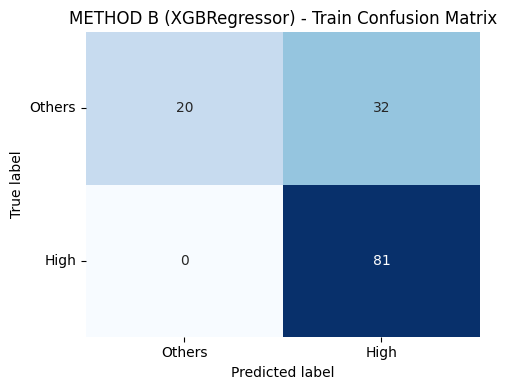

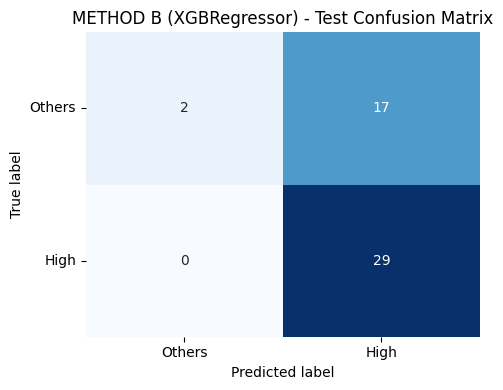

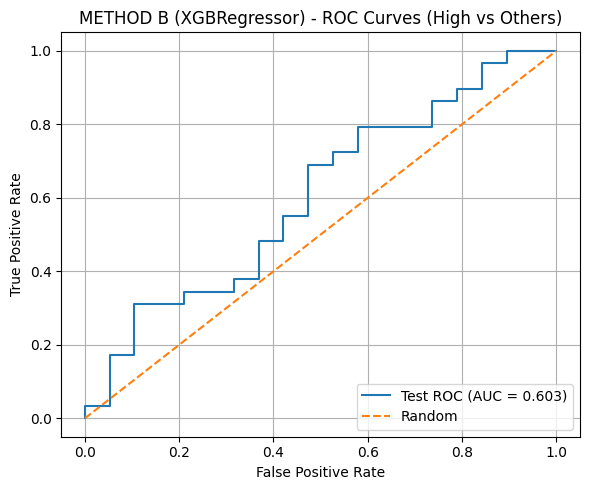

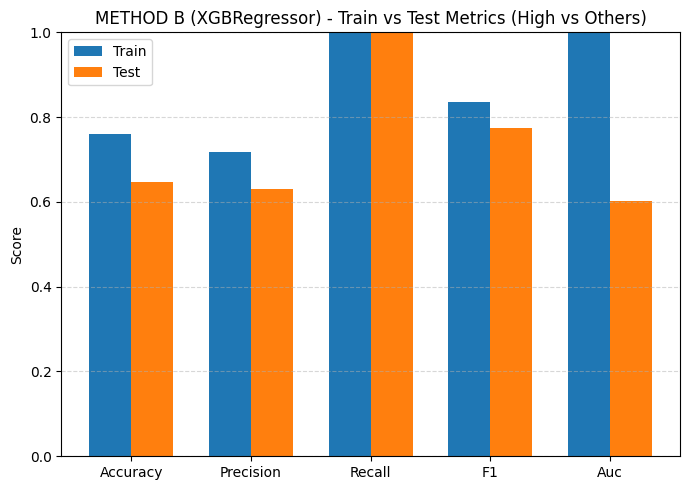

In [69]:
# ============================================================================
# 8. VISUALIZATION FOR METHOD B (XGBoostRegressor ordinal + threshold)
# ============================================================================

# ------------------------ 8.1 Recover predictions --------------------------

best_thr_B = results_B["best_threshold"]

# Continuous predictions on train and test
train_scores_B = results_B["train_pred_cont"]
test_scores_B = results_B["test_pred_cont"]

# Binary predictions using tuned threshold (High vs Others)
train_bin_pred_B = (train_scores_B >= best_thr_B).astype(int)
test_bin_pred_B = (test_scores_B >= best_thr_B).astype(int)

# ------------------------ 8.2 Confusion matrices ---------------------------

cm_train_B = confusion_matrix(y_train_bin_high, train_bin_pred_B)
cm_test_B = confusion_matrix(y_test_bin_high, test_bin_pred_B)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_train_B, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("METHOD B (XGBRegressor) - Train Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0.5, 1.5], ["Others", "High"])
plt.yticks([0.5, 1.5], ["Others", "High"], rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test_B, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("METHOD B (XGBRegressor) - Test Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0.5, 1.5], ["Others", "High"])
plt.yticks([0.5, 1.5], ["Others", "High"], rotation=0)
plt.tight_layout()
plt.show()

# ------------------------ 8.3 ROC curves -----------------------------------

# Use OOF predictions for train ROC to avoid target leakage
oof_scores_B = results_B["oof_pred"]

fpr_train_B, tpr_train_B, _ = roc_curve(y_train_bin_high, oof_scores_B)
roc_auc_train_B = auc(fpr_train_B, tpr_train_B)

# Test ROC uses final model predictions on test
fpr_test_B, tpr_test_B, _ = roc_curve(y_test_bin_high, test_scores_B)
roc_auc_test_B = auc(fpr_test_B, tpr_test_B)

plt.figure(figsize=(6, 5))
# plt.plot(fpr_train_B, tpr_train_B, label=f"Train (OOF) ROC (AUC = {roc_auc_train_B:.3f})")
plt.plot(fpr_test_B, tpr_test_B, label=f"Test ROC (AUC = {roc_auc_test_B:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("METHOD B (XGBRegressor) - ROC Curves (High vs Others)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------ 8.4 Train vs Test metric bar chart ---------------

train_metrics_B = results_B["train_metrics_bin"]
test_metrics_B = results_B["test_metrics_bin"]

metric_names = ["accuracy", "precision", "recall", "f1", "auc"]
train_values_B = [train_metrics_B[m] for m in metric_names]
test_values_B = [test_metrics_B[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width / 2, train_values_B, width, label="Train")
plt.bar(x + width / 2, test_values_B, width, label="Test")

plt.xticks(x, [m.capitalize() for m in metric_names])
plt.ylim(0.0, 1.0)
plt.ylabel("Score")
plt.title("METHOD B (XGBRegressor) - Train vs Test Metrics (High vs Others)")
plt.legend(loc="best")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [72]:
# ============================================================================
# HELPER FUNCTIONS FOR 3-CLASS LABELS AND ORDINAL CV
# ============================================================================

import itertools

def make_3class_labels(scores, low_thr, high_thr):
    """
    Map continuous scores into 3 ordinal classes:
      0: Low    (score < low_thr)
      1: Medium (low_thr <= score < high_thr)
      2: High   (score >= high_thr)
    """
    labels = np.zeros_like(scores, dtype=int)
    labels[scores >= low_thr] = 1
    labels[scores >= high_thr] = 2
    return labels


def ordinal_cv_score_with_threshold(
    X,
    y_ord,
    y_bin_high,
    model,
    thr_min=0.5,
    thr_max=2.5,
    thr_step=0.05,
    n_splits=5,
    random_state=42,
):
    """
    Perform stratified K-fold CV for an ordinal regression model (targets 0/1/2):
      1. Fit model on K-1 folds, predict continuous scores on the held-out fold.
      2. Aggregate OOF predictions.
      3. Search best threshold for "High vs Others" classification.
      4. Return best threshold and corresponding CV metrics.

    Returns:
      best_thr, best_cv_acc, best_cv_f1
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_pred = np.zeros_like(y_ord, dtype=float)

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X, y_bin_high), 1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr = y_ord[tr_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)
        oof_pred[val_idx] = m.predict(X_val)

        # You can uncomment this if you want to see per-fold logs
        # print(f"  Fold {fold_idx} completed.")

    thresholds = np.arange(thr_min, thr_max + thr_step, thr_step)
    best_thr = None
    best_acc = -1.0
    best_f1 = -1.0

    for thr in thresholds:
        bin_pred = (oof_pred >= thr).astype(int)
        acc = accuracy_score(y_bin_high, bin_pred)
        f1 = f1_score(y_bin_high, bin_pred)

        if acc > best_acc or (np.isclose(acc, best_acc) and f1 > best_f1):
            best_thr = thr
            best_acc = acc
            best_f1 = f1

    return best_thr, best_acc, best_f1


In [119]:
# ============================================================================
# GRID SEARCH OVER (low_thr, high_thr) FOR 3-CLASS BUCKETS
# ============================================================================

low_grid = np.arange(0.51, 0.78, 0.02)   # e.g. 0.55, 0.57, ..., 0.69
high_grid = np.arange(0.80, 0.82, 0.02)  # e.g. 0.70, 0.72, ..., 0.90

min_samples_per_class = 5   # skip thresholds that yield too few samples in any class

best_pair = None
best_pair_thr = None
best_pair_cv_f1 = -1.0
best_pair_cv_acc = -1.0

results_grid = []

print("Starting grid search for (low_thr, high_thr)...\n")

for low_thr in low_grid:
    for high_thr in high_grid:
        # Ensure ordering and a reasonable gap between low and high
        if high_thr - low_thr < 0.05:
            continue

        # Build 3-class labels for train set
        y_train_3_tmp = make_3class_labels(y_train_score, low_thr, high_thr)
        counts = np.bincount(y_train_3_tmp)

        # Skip if any class is too small
        if len(counts) < 3 or counts.min() < min_samples_per_class:
            continue

        # Binary labels: High (class 2) vs Others
        y_train_bin_tmp = (y_train_3_tmp == 2).astype(int)
        bin_counts = np.bincount(y_train_bin_tmp)
        if bin_counts.min() < min_samples_per_class:
            continue

        # Define a base XGBoostRegressor (no heavy tuning yet)
        base_reg = XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            tree_method="auto",
        )

        best_thr, cv_acc, cv_f1 = ordinal_cv_score_with_threshold(
            X=X_train,
            y_ord=y_train_3_tmp.astype(float),
            y_bin_high=y_train_bin_tmp,
            model=base_reg,
            thr_min=0.5,
            thr_max=2.5,
            thr_step=0.05,
            n_splits=5,
            random_state=42,
        )

        results_grid.append(
            (low_thr, high_thr, best_thr, cv_acc, cv_f1, counts.tolist(), bin_counts.tolist())
        )

        # Use CV F1 as the primary objective, then CV accuracy
        if cv_f1 > best_pair_cv_f1 or (np.isclose(cv_f1, best_pair_cv_f1) and cv_acc > best_pair_cv_acc):
            best_pair = (low_thr, high_thr)
            best_pair_thr = best_thr
            best_pair_cv_f1 = cv_f1
            best_pair_cv_acc = cv_acc

            print(
                f"New best pair: low={low_thr:.3f}, high={high_thr:.3f}, "
                f"cv_acc={cv_acc:.4f}, cv_f1={cv_f1:.4f}, best_thr={best_thr:.3f}, "
                f"class_counts={counts}, bin_counts={bin_counts}"
            )

print("\nGrid search completed.")
print("Best (low_thr, high_thr):", best_pair)
print("Best CV F1:", best_pair_cv_f1)
print("Best CV accuracy:", best_pair_cv_acc)
print("Best internal threshold (High vs Others):", best_pair_thr)


Starting grid search for (low_thr, high_thr)...

  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
New best pair: low=0.570, high=0.800, cv_acc=0.6015, cv_f1=0.7512, best_thr=0.500, class_counts=[ 7 45 81], bin_counts=[52 81]
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
New best pair: low=0.650, high=0.800, cv_acc=0.6241, cv_f1=0.7642, best_thr=0.550, class_counts=[20 32 81], bin_counts=[52 81]
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 complete

In [121]:
# ============================================================================
# HYPERPARAMETER TUNING FOR XGBRegressor ON BEST (low_thr, high_thr)
# ============================================================================

# Use the best thresholds from previous grid search
best_low_thr, best_high_thr = best_pair

# Rebuild 3-class and binary labels with the best thresholds
y_train_3_best = make_3class_labels(y_train_score, best_low_thr, best_high_thr)
y_test_3_best = make_3class_labels(y_test_score, best_low_thr, best_high_thr)

y_train_bin_best = (y_train_3_best == 2).astype(int)
y_test_bin_best = (y_test_3_best == 2).astype(int)

print("\nUsing best thresholds:")
print(f"  low_thr  = {best_low_thr:.3f}")
print(f"  high_thr = {best_high_thr:.3f}")
print("Train 3-class counts:", np.bincount(y_train_3_best))
print("Test  3-class counts:", np.bincount(y_test_3_best))
print("Train binary (High vs Others):", np.bincount(y_train_bin_best))
print("Test  binary (High vs Others):", np.bincount(y_test_bin_best))

# Define a small hyperparameter grid for XGBRegressor
param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "learning_rate": [0.03, 0.07],
}

best_params = None
best_model_thr = None
best_cv_f1_hp = -1.0
best_cv_acc_hp = -1.0

print("\nStarting hyperparameter search for XGBRegressor...\n")

for max_depth in param_grid["max_depth"]:
    for min_child_weight in param_grid["min_child_weight"]:
        for subsample in param_grid["subsample"]:
            for colsample_bytree in param_grid["colsample_bytree"]:
                for learning_rate in param_grid["learning_rate"]:
                    reg_hp = XGBRegressor(
                        objective="reg:squarederror",
                        n_estimators=400,
                        max_depth=max_depth,
                        min_child_weight=min_child_weight,
                        learning_rate=learning_rate,
                        subsample=subsample,
                        colsample_bytree=colsample_bytree,
                        random_state=42,
                        tree_method="auto",
                    )

                    best_thr_hp, cv_acc_hp, cv_f1_hp = ordinal_cv_score_with_threshold(
                        X=X_train,
                        y_ord=y_train_3_best.astype(float),
                        y_bin_high=y_train_bin_best,
                        model=reg_hp,
                        thr_min=0.5,
                        thr_max=2.5,
                        thr_step=0.05,
                        n_splits=5,
                        random_state=42,
                    )

                    # Update best hyperparams based on CV F1, then CV accuracy
                    if cv_f1_hp > best_cv_f1_hp or (
                        np.isclose(cv_f1_hp, best_cv_f1_hp) and cv_acc_hp > best_cv_acc_hp
                    ):
                        best_cv_f1_hp = cv_f1_hp
                        best_cv_acc_hp = cv_acc_hp
                        best_params = dict(
                            max_depth=max_depth,
                            min_child_weight=min_child_weight,
                            subsample=subsample,
                            colsample_bytree=colsample_bytree,
                            learning_rate=learning_rate,
                        )
                        best_model_thr = best_thr_hp

                        print(
                            f"New best params: {best_params}, "
                            f"CV acc={cv_acc_hp:.4f}, CV f1={cv_f1_hp:.4f}, "
                            f"best_thr={best_thr_hp:.3f}"
                        )

print("\nHyperparameter search completed.")
print("Best params:", best_params)
print("Best CV F1:", best_cv_f1_hp)
print("Best CV accuracy:", best_cv_acc_hp)
print("Best threshold (High vs Others):", best_model_thr)

# ============================================================================
# FINAL MODEL TRAINING AND EVALUATION WITH BEST SETTINGS
# ============================================================================

best_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    max_depth=best_params["max_depth"],
    min_child_weight=best_params["min_child_weight"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    random_state=42,
    tree_method="auto",
)

# Fit on full training data with ordinal targets {0,1,2}
best_reg.fit(X_train, y_train_3_best.astype(float))

# Continuous predictions
train_pred_cont = best_reg.predict(X_train)
test_pred_cont = best_reg.predict(X_test)

# Binary predictions using tuned threshold
train_bin_pred_final = (train_pred_cont >= best_model_thr).astype(int)
test_bin_pred_final = (test_pred_cont >= best_model_thr).astype(int)

print("\nFinal performance with best thresholds and hyperparameters:")

final_train_metrics = report_binary_metrics(
    "FINAL - Train", y_train_bin_best, train_pred_cont, train_bin_pred_final
)
final_test_metrics = report_binary_metrics(
    "FINAL - Test", y_test_bin_best, test_pred_cont, test_bin_pred_final
)



Using best thresholds:
  low_thr  = 0.650
  high_thr = 0.800
Train 3-class counts: [20 32 81]
Test  3-class counts: [10  9 29]
Train binary (High vs Others): [52 81]
Test  binary (High vs Others): [19 29]

Starting hyperparameter search for XGBRegressor...

  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
New best params: {'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 0.7, 'learning_rate': 0.03}, CV acc=0.6241, CV f1=0.7596, best_thr=0.750
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
New best params: {'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 1.0, 'learning_rate': 0.03}, CV acc=0.6165, CV f1=0.7606, best_thr=0.550
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
  Fol

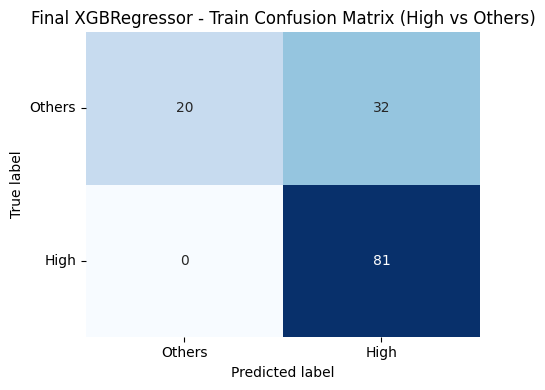

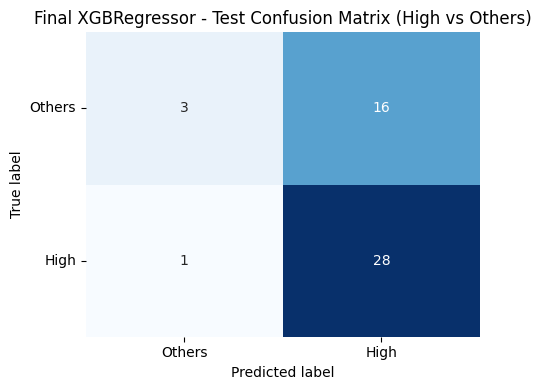

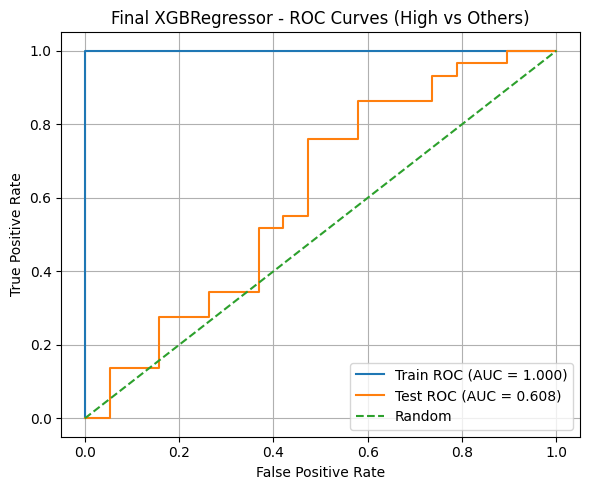

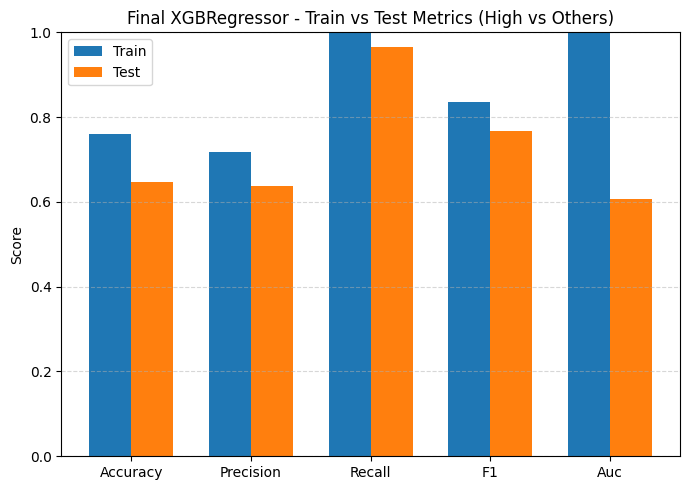

In [112]:
# ============================================================================
# VISUALIZATION FOR FINAL XGBRegressor (ordinal + threshold)
# ============================================================================

best_thr = best_model_thr  # tuned threshold for High vs Others

# ---------------------------------------------------------------------------
# 1. Confusion matrices (Train and Test)
# ---------------------------------------------------------------------------

cm_train_final = confusion_matrix(y_train_bin_best, train_bin_pred_final)
cm_test_final = confusion_matrix(y_test_bin_best, test_bin_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_train_final, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Final XGBRegressor - Train Confusion Matrix (High vs Others)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0.5, 1.5], ["Others", "High"])
plt.yticks([0.5, 1.5], ["Others", "High"], rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test_final, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Final XGBRegressor - Test Confusion Matrix (High vs Others)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0.5, 1.5], ["Others", "High"])
plt.yticks([0.5, 1.5], ["Others", "High"], rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 2. ROC curves (Train and Test)
# ---------------------------------------------------------------------------
# Note: Train ROC uses in-sample predictions (there is some target leakage).
# For a leak-free ROC, you would need to use OOF predictions from CV.

fpr_train_final, tpr_train_final, _ = roc_curve(y_train_bin_best, train_pred_cont)
roc_auc_train_final = auc(fpr_train_final, tpr_train_final)

fpr_test_final, tpr_test_final, _ = roc_curve(y_test_bin_best, test_pred_cont)
roc_auc_test_final = auc(fpr_test_final, tpr_test_final)

plt.figure(figsize=(6, 5))
plt.plot(fpr_train_final, tpr_train_final,
         label=f"Train ROC (AUC = {roc_auc_train_final:.3f})")
plt.plot(fpr_test_final, tpr_test_final,
         label=f"Test ROC (AUC = {roc_auc_test_final:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final XGBRegressor - ROC Curves (High vs Others)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 3. Bar chart: Train vs Test metrics comparison
# ---------------------------------------------------------------------------

# final_train_metrics / final_test_metrics are returned from report_binary_metrics
metric_names = ["accuracy", "precision", "recall", "f1", "auc"]
train_values = [final_train_metrics[m] for m in metric_names]
test_values = [final_test_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width / 2, train_values, width, label="Train")
plt.bar(x + width / 2, test_values, width, label="Test")

plt.xticks(x, [m.capitalize() for m in metric_names])
plt.ylim(0.0, 1.0)
plt.ylabel("Score")
plt.title("Final XGBRegressor - Train vs Test Metrics (High vs Others)")
plt.legend(loc="best")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [120]:
# ============================================================================
# HYPERPARAMETER TUNING FOR XGBRegressor ON BEST (low_thr, high_thr)
# ============================================================================

# Use the best thresholds from previous grid search
best_low_thr, best_high_thr = best_pair

# Rebuild 3-class and binary labels with the best thresholds
y_train_3_best = make_3class_labels(y_train_score, best_low_thr, best_high_thr)
y_test_3_best = make_3class_labels(y_test_score, best_low_thr, best_high_thr)

y_train_bin_best = (y_train_3_best == 2).astype(int)
y_test_bin_best = (y_test_3_best == 2).astype(int)

print("\nUsing best thresholds:")
print(f"  low_thr  = {best_low_thr:.3f}")
print(f"  high_thr = {best_high_thr:.3f}")
print("Train 3-class counts:", np.bincount(y_train_3_best))
print("Test  3-class counts:", np.bincount(y_test_3_best))
print("Train binary (High vs Others):", np.bincount(y_train_bin_best))
print("Test  binary (High vs Others):", np.bincount(y_test_bin_best))

# ============================================================================
# Feature selection: select top-k most informative features
# ============================================================================

# Number of features to keep (you can adjust this)
k_features = min(20, X_train.shape[1])

# Use mutual information with the binary "High vs Others" label
selector = SelectKBest(mutual_info_classif, k=k_features)
X_train_fs = selector.fit_transform(X_train, y_train_bin_best)
X_test_fs = selector.transform(X_test)

print(f"\nFeature selection:")
print(f"  Original #features: {X_train.shape[1]}")
print(f"  Selected #features: {X_train_fs.shape[1]}")

# ============================================================================
# Hyperparameter grid for XGBRegressor (with regularization and gamma)
# ============================================================================

param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [1, 3],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.7, 1.0],
    "learning_rate": [0.03, 0.07],
    "reg_lambda": [0.0, 1.0, 5.0],
    "reg_alpha": [0.0, 0.5],
    "gamma": [0.0, 1.0],
}

best_params = None
best_model_thr = None
best_cv_f1_hp = -1.0
best_cv_acc_hp = -1.0

print("\nStarting hyperparameter search for XGBRegressor...\n")

for max_depth in param_grid["max_depth"]:
    for min_child_weight in param_grid["min_child_weight"]:
        for subsample in param_grid["subsample"]:
            for colsample_bytree in param_grid["colsample_bytree"]:
                for learning_rate in param_grid["learning_rate"]:
                    for reg_lambda in param_grid["reg_lambda"]:
                        for reg_alpha in param_grid["reg_alpha"]:
                            for gamma in param_grid["gamma"]:
                                reg_hp = XGBRegressor(
                                    objective="reg:squarederror",
                                    n_estimators=400,
                                    max_depth=max_depth,
                                    min_child_weight=min_child_weight,
                                    learning_rate=learning_rate,
                                    subsample=subsample,
                                    colsample_bytree=colsample_bytree,
                                    reg_lambda=reg_lambda,
                                    reg_alpha=reg_alpha,
                                    gamma=gamma,
                                    random_state=42,
                                    tree_method="auto",
                                )

                                best_thr_hp, cv_acc_hp, cv_f1_hp = ordinal_cv_score_with_threshold(
                                    X=X_train_fs,
                                    y_ord=y_train_3_best.astype(float),
                                    y_bin_high=y_train_bin_best,
                                    model=reg_hp,
                                    thr_min=0.5,
                                    thr_max=2.5,
                                    thr_step=0.05,
                                    n_splits=5,
                                    random_state=42,
                                )

                                # Update best hyperparams based on CV F1, then CV accuracy
                                if cv_f1_hp > best_cv_f1_hp or (
                                    np.isclose(cv_f1_hp, best_cv_f1_hp) and cv_acc_hp > best_cv_acc_hp
                                ):
                                    best_cv_f1_hp = cv_f1_hp
                                    best_cv_acc_hp = cv_acc_hp
                                    best_params = dict(
                                        max_depth=max_depth,
                                        min_child_weight=min_child_weight,
                                        subsample=subsample,
                                        colsample_bytree=colsample_bytree,
                                        learning_rate=learning_rate,
                                        reg_lambda=reg_lambda,
                                        reg_alpha=reg_alpha,
                                        gamma=gamma,
                                    )
                                    best_model_thr = best_thr_hp

                                    print(
                                        f"New best params: {best_params}, "
                                        f"CV acc={cv_acc_hp:.4f}, CV f1={cv_f1_hp:.4f}, "
                                        f"best_thr={best_thr_hp:.3f}"
                                    )

print("\nHyperparameter search completed.")
print("Best params:", best_params)
print("Best CV F1:", best_cv_f1_hp)
print("Best CV accuracy:", best_cv_acc_hp)
print("Best threshold (High vs Others):", best_model_thr)

# ============================================================================
# FINAL MODEL TRAINING AND EVALUATION WITH BEST SETTINGS
# ============================================================================

best_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    max_depth=best_params["max_depth"],
    min_child_weight=best_params["min_child_weight"],
    learning_rate=best_params["learning_rate"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    reg_lambda=best_params["reg_lambda"],
    reg_alpha=best_params["reg_alpha"],
    gamma=best_params["gamma"],
    random_state=42,
    tree_method="auto",
)

# Fit on full training data with ordinal targets {0,1,2}, using selected features
best_reg.fit(X_train_fs, y_train_3_best.astype(float))

# Continuous predictions
train_pred_cont = best_reg.predict(X_train_fs)
test_pred_cont = best_reg.predict(X_test_fs)

# Binary predictions using tuned threshold
train_bin_pred_final = (train_pred_cont >= best_model_thr).astype(int)
test_bin_pred_final = (test_pred_cont >= best_model_thr).astype(int)

print("\nFinal performance with best thresholds, hyperparameters, and feature selection:")

final_train_metrics = report_binary_metrics(
    "FINAL - Train", y_train_bin_best, train_pred_cont, train_bin_pred_final
)
final_test_metrics = report_binary_metrics(
    "FINAL - Test", y_test_bin_best, test_pred_cont, test_bin_pred_final
)



Using best thresholds:
  low_thr  = 0.650
  high_thr = 0.800
Train 3-class counts: [20 32 81]
Test  3-class counts: [10  9 29]
Train binary (High vs Others): [52 81]
Test  binary (High vs Others): [19 29]

Feature selection:
  Original #features: 31
  Selected #features: 20

Starting hyperparameter search for XGBRegressor...

  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
New best params: {'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 0.7, 'learning_rate': 0.03, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'gamma': 0.0}, CV acc=0.6391, CV f1=0.7624, best_thr=0.850
  Fold 1 completed.
  Fold 2 completed.
  Fold 3 completed.
  Fold 4 completed.
  Fold 5 completed.
New best params: {'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.7, 'colsample_bytree': 0.7, 'learning_rate': 0.03, 'reg_lambda': 0.0, 'reg_alpha': 0.0, 'gamma': 1.0}, CV acc=0.6541, CV f1=0.7677, best_thr=1.000
  Fold 1 completed.
  Fold 2 comp

In [129]:
# ============================================================================
# PREDICT ON NEW DATA AND SAVE RESULTS
# ============================================================================

# Path to the file that contains features for prediction
to_predict_path = "integrated_features/data/to_predict_x.csv"

# Load and sort by video_id (for consistency)
to_pred_df = pd.read_csv(to_predict_path).sort_values("video_id").reset_index(drop=True)

print("To-predict shape:", to_pred_df.shape)
print("Columns in to_predict_x:", list(to_pred_df.columns))

# ---------------------------------------------------------------------------
# 1. Build full feature matrix using the same feature order as training
# ---------------------------------------------------------------------------

# Use exactly the same feature columns as in X_train, in the same order
X_pred_full = to_pred_df[feature_names].values
n_features_full = X_pred_full.shape[1]
print("X_pred_full shape:", X_pred_full.shape)

# ---------------------------------------------------------------------------
# 2. Match feature shape with the trained model
# ---------------------------------------------------------------------------

# Number of features the model was trained with
if hasattr(best_reg, "n_features_in_"):
    n_model = best_reg.n_features_in_
else:
    # Fallback: assume it matches full features
    n_model = n_features_full

print("Model was trained with", n_model, "features.")

# Determine how many features the selector keeps (if it exists)
selector_used = False
k_selected = None
if "selector" in globals():
    try:
        support_mask = selector.get_support()
        k_selected = int(support_mask.sum())
        print("Selector keeps", k_selected, "features.")
    except Exception as e:
        print("Selector found but get_support() failed:", e)

# Decide which feature matrix to feed into the model
if selector_used is False and k_selected is not None and n_model == k_selected:
    # Case 1: model was trained on selected features
    X_pred_for_model = selector.transform(X_pred_full)
    selector_used = True
    print("Using selector.transform(X_pred_full) for prediction.")
elif n_model == n_features_full:
    # Case 2: model was trained on all features
    X_pred_for_model = X_pred_full
    print("Using full feature matrix for prediction (no feature reduction).")
elif k_selected is not None and n_model == k_selected:
    # Case 3: same as first branch, but we did not set selector_used earlier
    X_pred_for_model = selector.transform(X_pred_full)
    selector_used = True
    print("Using selector.transform(X_pred_full) for prediction.")
else:
    # Shape mismatch: let the user know clearly
    raise ValueError(
        f"Cannot match feature shapes: model expects {n_model}, "
        f"full features = {n_features_full}, selector k = {k_selected}. "
        "Please ensure best_reg is trained consistently with (selector / no selector)."
    )

print("X_pred_for_model shape:", X_pred_for_model.shape)

# ---------------------------------------------------------------------------
# 3. Predict continuous scores and then 0/1 labels
# ---------------------------------------------------------------------------

# Continuous ordinal scores from the trained XGBRegressor
pred_scores = best_reg.predict(X_pred_for_model)

# Binary labels using the tuned threshold:
#   1 = understandable (High), 0 = not-high (Others)
pred_labels = (pred_scores >= best_model_thr).astype(int)

# ---------------------------------------------------------------------------
# 4. Build output DataFrame and save to CSV
# ---------------------------------------------------------------------------

output_df = pd.DataFrame({
    "video_id": to_pred_df["video_id"],
    "label": pred_labels,
})

save_path = "integrated_features/data/to_predict_y_xgb_final.csv"
output_df.to_csv(save_path, index=False)

print(f"\nSaved predictions to: {save_path}")
print(output_df.head())


To-predict shape: (2297, 32)
Columns in to_predict_x: ['video_id', 'meta_has_title', 'meta_has_description', 'meta_video_duration', 'meta_description_unique_words', 'meta_like_count', 'meta_comment_count', 'meta_subscriber_count', 'meta_sentiment', 'average_word_length', 'lexical_diversity', 'medical_density', 'medical_mention_count', 'rare_term_ratio_unique', 'term_clustering_concentrated', 'term_clustering_gini', 'condition_ratio', 'symptom_ratio', 'therapy_ratio', 'medication_ratio', 'anatomy_ratio', 'location_ratio', 'measurement_ratio', 'activity_ratio', 'other_ratio', 'passive_voice_ratio', 'sentence_length_std', 'syntax_tree_depth', 'subordinate_clause_density', 'average_dependency_distance', 'pronoun_frequency', 'word_count']
X_pred_full shape: (2297, 31)
Model was trained with 31 features.
Selector keeps 20 features.
Using full feature matrix for prediction (no feature reduction).
X_pred_for_model shape: (2297, 31)

Saved predictions to: classifier/integrated_features/data/to_

In [131]:
# Load the prediction file
pred_path = "integrated_features/data/to_predict_y_xgb_final.csv"
df_pred = pd.read_csv(pred_path)

# Count 0 and 1
counts = df_pred["label"].value_counts().sort_index()

num_0 = counts.get(0, 0)
num_1 = counts.get(1, 0)
total = num_0 + num_1

print("\nPrediction label distribution:")
print(f"  0 (not understandable): {num_0}")
print(f"  1 (understandable):     {num_1}")
print(f"  Total:                   {total}")

if total > 0:
    print(f"\nProportions:")
    print(f"  0 ratio: {num_0 / total:.4f}")
    print(f"  1 ratio: {num_1 / total:.4f}")



Prediction label distribution:
  0 (not understandable): 190
  1 (understandable):     2107
  Total:                   2297

Proportions:
  0 ratio: 0.0827
  1 ratio: 0.9173


In [141]:
import pandas as pd

# Paths
pred_path = "integrated_features/data/to_predict_y_xgb_final.csv"
train_path = "integrated_features/data/train_y.csv"
test_path = "integrated_features/data/test_y.csv"

# ---------------------------------------
# 1. Load prediction results
# ---------------------------------------
df_pred = pd.read_csv(pred_path)[["video_id", "label"]]

# Add flag: predicted = 1
df_pred["is_predicted_human"] = 1

# ---------------------------------------
# 2. Load train/test ground truth
# ---------------------------------------
df_train = pd.read_csv(train_path)  # columns: video_id, label
df_test = pd.read_csv(test_path)

# Concatenate train + test
df_gt = pd.concat([df_train, df_test], ignore_index=True)

# Rename column for consistency
df_gt = df_gt.rename(columns={"label": "score"})

# ---------------------------------------
# 3. Convert continuous score → 0/1
# ---------------------------------------
df_gt["label"] = (df_gt["score"] >= 0.8).astype(int)

# Only keep needed columns
df_gt = df_gt[["video_id", "label"]]

# Add flag: human = 0
df_gt["is_predicted_human"] = 0

# ---------------------------------------
# 4. Combine prediction + ground truth
# ---------------------------------------
df_all = pd.concat([df_pred, df_gt], ignore_index=True)

# ---------------------------------------
# 5. Save final combined file
# ---------------------------------------
output_path = "integrated_features/data/to_predict_y_xgb_final.csv"
df_all.to_csv(output_path, index=False)

print("Saved combined file to:", output_path)
print(df_all.head())
print("\nTotal rows:", len(df_all))
print(df_all["label"].value_counts())
print(df_all["is_predicted_human"].value_counts())


Saved combined file to: classifier/integrated_features/data/to_predict_y_xgb_final.csv
      video_id  label  is_predicted_human
0  --uQR16bKD8      1                   1
1  -8wPY3vFR_A      1                   1
2  -B-HaLGqQRM      0                   1
3  -DGB139NQg8      0                   1
4  -DgvdrXc3ko      1                   1

Total rows: 2486
label
1    2219
0     267
Name: count, dtype: int64
is_predicted_human
1    2297
0     189
Name: count, dtype: int64


In [142]:
import pandas as pd

file1 = "integrated_features/data/AI_final_result.csv"
file2 = "integrated_features/data/to_predict_y_xgb_final.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

print("df1:", df1.shape)
print("df2:", df2.shape)

df_merged = df1.merge(df2, on="video_id", how="left")

print("Merged shape:", df_merged.shape)

# save
output_path = "integrated_features/data/final_merged.csv"
df_merged.to_csv(output_path, index=False)

print("Saved to:", output_path)
print(df_merged.head())


df1: (2474, 3)
df2: (2486, 3)
Merged shape: (2474, 5)
Saved to: classifier/integrated_features/data/final_merged.csv
      video_id  is_understandable  is_predicted  label  is_predicted_human
0  0H_xTEHRK0g                  0             0    1.0                 0.0
1  1KceELBEzgw                  0             0    1.0                 0.0
2  1hKkuOSe2vw                  1             0    1.0                 0.0
3  2WOM6we0SyM                  0             0    0.0                 0.0
4  2uD0VmPdGIE                  0             0    0.0                 0.0


In [144]:
import pandas as pd

path = "integrated_features/data/final_merged.csv"

df = pd.read_csv(path)

# ---------------------------------------------------
# 1. Rename columns
# ---------------------------------------------------
df = df.rename(columns={
    "is_understandable": "label_AI",
    "is_predicted": "is_predicted_AI",
    "label": "label_human"
})

# ---------------------------------------------------
# 2. Convert values to integers (0/1)
# ---------------------------------------------------
cols_to_fix = ["label_AI", "is_predicted_AI", "label_human", "is_predicted_human"]

for col in cols_to_fix:
    if col in df.columns:
        df[col] = df[col].astype(float).astype(int)

# ---------------------------------------------------
# 3. Save cleaned file
# ---------------------------------------------------
output_path = "integrated_features/data/final_merged_clean.csv"
df.to_csv(output_path, index=False)

print("Saved to:", output_path)
print(df.head())
print(df.dtypes)


Saved to: classifier/integrated_features/data/final_merged_clean.csv
      video_id  label_AI  is_predicted_AI  label_human  is_predicted_human
0  0H_xTEHRK0g         0                0            1                   0
1  1KceELBEzgw         0                0            1                   0
2  1hKkuOSe2vw         1                0            1                   0
3  2WOM6we0SyM         0                0            0                   0
4  2uD0VmPdGIE         0                0            0                   0
video_id              object
label_AI               int64
is_predicted_AI        int64
label_human            int64
is_predicted_human     int64
dtype: object


In [145]:
# --------------------------------------------------------------------
# 1. Load GPT-5 recommendation results (Excel)
# --------------------------------------------------------------------
gpt5_path = "integrated_features/data/youtube_database_export_gpt5_results.xlsx"
df_gpt5 = pd.read_excel(gpt5_path)

print("GPT-5 results shape:", df_gpt5.shape)
print("Columns:", df_gpt5.columns.tolist())

# --------------------------------------------------------------------
# 2. Filter rows where Recommendation_gpt_5 == 1
# --------------------------------------------------------------------
df_gpt5_rec = df_gpt5[df_gpt5["Recommendation_gpt_5"] == 1].copy()
print("GPT-5 recommended rows:", len(df_gpt5_rec))

rec_video_ids = df_gpt5_rec["video_id"].astype(str).unique()
print("Unique recommended video_ids:", len(rec_video_ids))

# --------------------------------------------------------------------
# 3. Load final_merged_clean.csv
# --------------------------------------------------------------------
merged_path = "integrated_features/data/final_merged_clean.csv"
df_full = pd.read_csv(merged_path)
df_full["video_id"] = df_full["video_id"].astype(str)

print("Full merged shape:", df_full.shape)

# --------------------------------------------------------------------
# 4. Inner join: keep only rows whose video_id is in the recommended list
# --------------------------------------------------------------------
df_rec_merged = df_full.merge(
    df_gpt5_rec[["video_id", "Recommendation_gpt_5"]],
    on="video_id",
    how="inner",
)

print("Filtered merged shape:", df_rec_merged.shape)

# --------------------------------------------------------------------
# 5. Save the filtered result
# --------------------------------------------------------------------
output_path = "integrated_features/data/final_merged_clean_gpt5_rec_only.csv"
df_rec_merged.to_csv(output_path, index=False)

print("Saved filtered result to:", output_path)
print(df_rec_merged.head())


GPT-5 results shape: (2363, 21)
Columns: ['video_id', 'channel_id', 'search_term', 'title', 'description', 'published_at', 'duration', 'view_count', 'like_count', 'comment_count', 'handle', 'channel_title', 'subscriber_count', 'video_count', 'channel_view_count', 'is_credible', 'caption_text', 'has_transcript', 'Category_gpt_5', 'Recommendation_gpt_5', 'Reasoning_gpt_5']
GPT-5 recommended rows: 867
Unique recommended video_ids: 867
Full merged shape: (2474, 5)
Filtered merged shape: (820, 6)
Saved filtered result to: classifier/integrated_features/data/final_merged_clean_gpt5_rec_only.csv
      video_id  label_AI  is_predicted_AI  label_human  is_predicted_human  \
0  0H_xTEHRK0g         0                0            1                   0   
1  1KceELBEzgw         0                0            1                   0   
2  1hKkuOSe2vw         1                0            1                   0   
3  4CCA9ojRAoU         1                0            1                   0   
4  7rDt5QGWZf0

Confusion Matrix:
[[ 11  29]
 [138 642]]

Classification Report:
              precision    recall  f1-score   support

           0       0.07      0.28      0.12        40
           1       0.96      0.82      0.88       780

    accuracy                           0.80       820
   macro avg       0.52      0.55      0.50       820
weighted avg       0.91      0.80      0.85       820



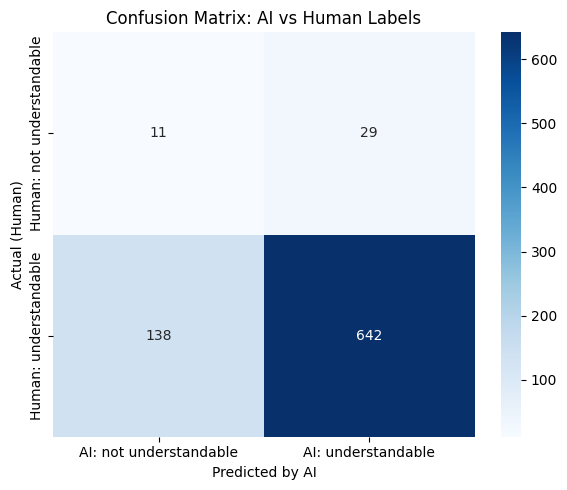

In [1]:
# ---------------------------------------------------------
# 1. Load the filtered dataset
# ---------------------------------------------------------
path = "integrated_features/data/final_merged_clean_gpt5_rec_only.csv"
df = pd.read_csv(path)

# Ensure integer type
df["label_AI"] = df["label_AI"].astype(int)
df["label_human"] = df["label_human"].astype(int)

# ---------------------------------------------------------
# 2. Compute confusion matrix
# ---------------------------------------------------------
cm = confusion_matrix(df["label_human"], df["label_AI"])

print("Confusion Matrix:")
print(cm)

# ---------------------------------------------------------
# 3. Optional: print classification metrics
# ---------------------------------------------------------
print("\nClassification Report:")
print(classification_report(df["label_human"], df["label_AI"]))

# ---------------------------------------------------------
# 4. Plot as heatmap
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AI: not understandable", "AI: understandable"],
            yticklabels=["Human: not understandable", "Human: understandable"])
plt.xlabel("Predicted by AI")
plt.ylabel("Actual (Human)")
plt.title("Confusion Matrix: AI vs Human Labels")
plt.tight_layout()
plt.show()


In [2]:
# ---------------------------------------------------------
# 1. Load the full dataset (Excel)
# ---------------------------------------------------------
full_path = "integrated_features/data/patient_education_videos_new_prompt_results.xlsx"
df_full = pd.read_excel(full_path)

df_full["video_id"] = df_full["video_id"].astype(str)

print("Full dataset shape:", df_full.shape)

# ---------------------------------------------------------
# 2. Load final_merged_clean.csv
# ---------------------------------------------------------
merged_path = "integrated_features/data/final_merged_clean.csv"
df_labels = pd.read_csv(merged_path)

df_labels["video_id"] = df_labels["video_id"].astype(str)

# We expect these 4 columns to exist:
cols_needed = ["video_id", "label_AI", "is_predicted_AI", "label_human", "is_predicted_human"]
df_labels = df_labels[cols_needed]

print("Label dataset shape:", df_labels.shape)

# ---------------------------------------------------------
# 3. Merge the labels into the full dataset
# ---------------------------------------------------------
df_joined = df_full.merge(df_labels, on="video_id", how="left")

print("Merged dataset shape:", df_joined.shape)

# ---------------------------------------------------------
# 4. Save the merged result
# ---------------------------------------------------------
output_path = "integrated_features/data/youtube_videos_full_with_labels.csv"
df_joined.to_csv(output_path, index=False)

print("Saved merged file to:", output_path)
print(df_joined.head())


Full dataset shape: (792, 24)
Label dataset shape: (2474, 5)
Merged dataset shape: (792, 28)
Saved merged file to: classifier/integrated_features/data/youtube_videos_full_with_labels.csv
      video_id                channel_id  \
0  fKyzKlYGZhA  UC41SJI79yjZIe96OajzN22g   
1  McEpJ7Dm1Rw  UCfp5MBK2IC90Bdm5IQUJvYw   
2  24v2zQHZUAE  UCfp5MBK2IC90Bdm5IQUJvYw   
3  vXxVFIgNTCE  UCNhXTS_yLO9HgFuiQuhf2AA   
4  U8ZVlKI_yoA  UCIGmH0KKedHt7sVPvKzZ11w   

                                         search_term  \
0  diet after lung transplant|diet before lung tr...   
1  heart transplant financial assistance|lung tra...   
2  diet after lung transplant|diet before lung tr...   
3  are lung transplants worth it|clad lung transp...   
4  diet after lung transplant|levels after lung t...   

                                               title  \
0  Long Term Care After Transplant | Lung Transpl...   
1  Updated Video Link Below: Financial Planning f...   
2  Nutrition and Lung Transplant  - U-M Hea

In [3]:
def parse_iso8601_duration(duration_str):
    """
    Convert ISO-8601 YouTube duration string (e.g., 'PT3M33S') into total minutes (float).
    Supports formats: PT#H#M#S, PT#M#S, PT#H#M, PT#M, etc.
    """
    if not isinstance(duration_str, str):
        return None

    pattern = r"PT(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?"
    match = re.match(pattern, duration_str)
    if not match:
        return None

    hours = int(match.group(1)) if match.group(1) else 0
    minutes = int(match.group(2)) if match.group(2) else 0
    seconds = int(match.group(3)) if match.group(3) else 0

    total_minutes = hours * 60 + minutes + seconds / 60
    return total_minutes


# =========================================================
# Apply duration parsing + filtering
# =========================================================

# Convert ISO8601 duration into minutes
df_joined["duration_minutes"] = df_joined["duration"].apply(parse_iso8601_duration)

# Filter: keep videos between 1 and 20 minutes
df_joined = df_joined[
    (df_joined["duration_minutes"] >= 1) &
    (df_joined["duration_minutes"] <= 20)
].copy()

print("Filtered by duration 1-20 minutes. Remaining:", len(df_joined))

# =========================================================
# Save final file
# =========================================================
output_path = "integrated_features/data/youtube_videos_full_with_labels.csv"
df_joined.to_csv(output_path, index=False)

print("Saved merged + duration-filtered file to:", output_path)
print(df_joined[["video_id", "duration", "duration_minutes"]].head())


Filtered by duration 1-20 minutes. Remaining: 585
Saved merged + duration-filtered file to: classifier/integrated_features/data/youtube_videos_full_with_labels.csv
      video_id duration  duration_minutes
0  fKyzKlYGZhA   PT3M8S          3.133333
1  McEpJ7Dm1Rw  PT3M35S          3.583333
2  24v2zQHZUAE  PT8M34S          8.566667
4  U8ZVlKI_yoA  PT4M11S          4.183333
5  o1XNQs21gGA   PT2M8S          2.133333


In [6]:
# ---------------------------------------------------------
# 1. Load your merged full dataset (CSV)
# ---------------------------------------------------------
csv_path = "integrated_features/data/youtube_videos_full_with_labels.csv"
df = pd.read_csv(csv_path)

# Convert video_id to string to avoid mismatches
df["video_id"] = df["video_id"].astype(str)

# ---------------------------------------------------------
# 2. Load Excel file that contains PEMAT Score and LLM Ranking
# ---------------------------------------------------------
excel_path = "integrated_features/data/youtube_videos_full_set.xlsx"
df_excel = pd.read_excel(excel_path)

# Convert video_id to string for consistent merging
df_excel["video_id"] = df_excel["video_id"].astype(str)

# Keep only the columns needed for merging
df_excel_subset = df_excel[
    ["video_id", "PEMAT Score", "LLM Ranking", "is_understandable"]
].drop_duplicates(subset=["video_id"])


# ---------------------------------------------------------
# 3. Merge PEMAT Score and LLM Ranking into main dataframe
# ---------------------------------------------------------
df = df.merge(
    df_excel_subset,
    on="video_id",
    how="left"
)

# Optional sanity check
print("Missing PEMAT Score after merge:", df["PEMAT Score"].isna().sum())
print("Missing LLM Ranking after merge:", df["LLM Ranking"].isna().sum())

# ---------------------------------------------------------
# 4. Filter Recommendation_gpt_5 == 1
# ---------------------------------------------------------
df_filtered = df[df["Recommendation_gpt_5"] == 1].copy()

print("Rows after filtering Recommendation_gpt_5 == 1:", df_filtered.shape[0])

# ---------------------------------------------------------
# 5. Select only the required columns
# ---------------------------------------------------------
cols_keep = [
    "video_id",
    "Category_gpt_5",
    "Recommendation_gpt_5",
    "is_understandable",
    "PEMAT Score",
    "LLM Ranking",
    "label_AI",
    "is_predicted_AI",
    "label_human",
    "is_predicted_human",
]

# Check for missing columns
missing = [c for c in cols_keep if c not in df_filtered.columns]
if missing:
    print("WARNING: Missing columns:", missing)

df_final = df_filtered[cols_keep]

# ---------------------------------------------------------
# 6. Save final file
# ---------------------------------------------------------
output_path = "integrated_features/data/youtube_final_filtered_for_analysis.csv"
df_final.to_csv(output_path, index=False)

print("Saved filtered file to:", output_path)
print(df_final.head())


Missing PEMAT Score after merge: 0
Missing LLM Ranking after merge: 0
Rows after filtering Recommendation_gpt_5 == 1: 559
Saved filtered file to: classifier/integrated_features/data/youtube_final_filtered_for_analysis.csv
      video_id                     Category_gpt_5  Recommendation_gpt_5  \
0  fKyzKlYGZhA   Patient education - post surgery                     1   
1  McEpJ7Dm1Rw  Patient education - consideration                     1   
2  24v2zQHZUAE   Patient education - post surgery                     1   
3  U8ZVlKI_yoA   Patient education - post surgery                     1   
4  o1XNQs21gGA       Patient Education - waitlist                     1   

   is_understandable  PEMAT Score  LLM Ranking  label_AI  is_predicted_AI  \
0                1.0     0.714286     0.785714       1.0              0.0   
1                1.0     0.571429     0.678571       1.0              1.0   
2                0.0     0.571429     0.428571       0.0              0.0   
3                1.

In [7]:
# ======================================================================
# 1. Load final file
# ======================================================================
path = "integrated_features/data/youtube_final_filtered_for_analysis.csv"
df = pd.read_csv(path)

# Ensure correct dtypes
numeric_cols = ["is_understandable", "PEMAT Score", "label_AI", "label_human"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# ======================================================================
# 2. Build a combined final_score (no LLM Ranking)
# ======================================================================
# Normalize PEMAT to [0, 1]
df["PEMAT_norm"] = (df["PEMAT Score"] / 100.0).clip(0, 1)

# Weights for each signal (sum to 1.0)
w_human = 0.30          # human-based label (most trusted)
w_ai = 0.30             # ML model label
w_llm_bin = 0.25        # LLM binary understandability
w_pemat = 0.15          # LLM PEMAT score

df["final_score"] = (
    w_human * df["label_human"]
    + w_ai * df["label_AI"]
    + w_llm_bin * df["is_understandable"]
    + w_pemat * df["PEMAT_norm"]
)

# ======================================================================
# 3. Decide total K and allocate K per category proportionally
# ======================================================================
# Total number of videos you want to recommend across all categories.
# You can change this to any integer you like (e.g., 50, 80, 100).
total_k = 100

n_total = len(df)
if total_k > n_total:
    total_k = n_total

# Count videos per category
category_counts = df["Category_gpt_5"].value_counts()
proportions = category_counts / n_total

# Initial allocation: round proportional counts
alloc = (proportions * total_k).round().astype(int)

# Ensure at least 1 video per category and not more than available
alloc[alloc < 1] = 1
alloc = alloc.clip(upper=category_counts)

# Adjust so that sum(alloc) ≈ total_k
delta = total_k - alloc.sum()
if delta != 0:
    # Modify the largest categories first until the sum matches total_k
    order = category_counts.sort_values(ascending=False).index.tolist()
    step = 1 if delta > 0 else -1
    delta_remaining = abs(delta)

    i = 0
    while delta_remaining > 0 and i < len(order):
        cat = order[i]
        new_val = alloc[cat] + step
        # Respect bounds: [1, category_counts[cat]]
        if 1 <= new_val <= category_counts[cat]:
            alloc[cat] = new_val
            delta_remaining -= 1
        else:
            i += 1
    # If still mismatch, the difference will be small and not critical.

print("Category sizes:")
print(category_counts)
print("\nAllocated K per category:")
print(alloc)

# ======================================================================
# 4. Select top-K per category based on final_score
# ======================================================================
# Sort by category then by final_score descending
df_sorted = df.sort_values(["Category_gpt_5", "final_score"], ascending=[True, False])

top_rows = []
for cat, k_cat in alloc.items():
    sub = df_sorted[df_sorted["Category_gpt_5"] == cat].head(k_cat)
    top_rows.append(sub)

df_top = pd.concat(top_rows, ignore_index=True)

# Add rank within each category
df_top["category_rank"] = (
    df_top.groupby("Category_gpt_5")["final_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# ======================================================================
# 5. Save final recommendations
# ======================================================================
out_path = "integrated_features/data/youtube_recommendations_topK_dynamic.csv"
df_top.to_csv(out_path, index=False)

print("\nSaved final recommendations to:", out_path)
print(df_top.head())


Category sizes:
Category_gpt_5
Patient education - consideration                            155
Patient education - post surgery                             141
Patient education - evaluation                               106
Patient education - surgery                                   95
Patient Education - waitlist                                  57
Promotional - introduce the hospital/ MD/ clinician story      5
Name: count, dtype: int64

Allocated K per category:
Category_gpt_5
Patient education - consideration                            28
Patient education - post surgery                             25
Patient education - evaluation                               19
Patient education - surgery                                  17
Patient Education - waitlist                                 10
Promotional - introduce the hospital/ MD/ clinician story     1
Name: count, dtype: int64

Saved final recommendations to: classifier/integrated_features/data/youtube_recommendations_topK_dyn

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the top-K recommendations (if not already in memory)
df_top = pd.read_csv(
    "integrated_features/data/youtube_recommendations_topK_dynamic.csv"
)

# Filter only "Patient Education" related categories
patient_mask = df_top["Category_gpt_5"].str.startswith("Patient", na=False)
df_patient = df_top[patient_mask].copy()

print("Patient Education videos in top-K:", len(df_patient))
print(df_patient["Category_gpt_5"].value_counts())


Patient Education videos in top-K: 99
Category_gpt_5
Patient education - consideration    28
Patient education - post surgery     25
Patient education - evaluation       19
Patient education - surgery          17
Patient Education - waitlist         10
Name: count, dtype: int64


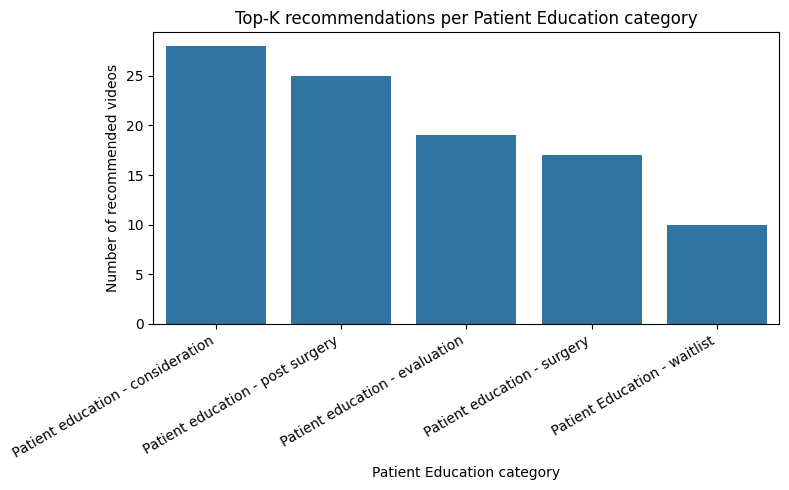

In [9]:
plt.figure(figsize=(8, 5))

# Count per category
cat_counts = df_patient["Category_gpt_5"].value_counts().sort_values(ascending=False)

sns.barplot(
    x=cat_counts.index,
    y=cat_counts.values
)

plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of recommended videos")
plt.xlabel("Patient Education category")
plt.title("Top-K recommendations per Patient Education category")
plt.tight_layout()
plt.show()


/var/folders/65/9clft3kn44nbk5467cp025hw0000gn/T/ipykernel_44263/3620358097.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


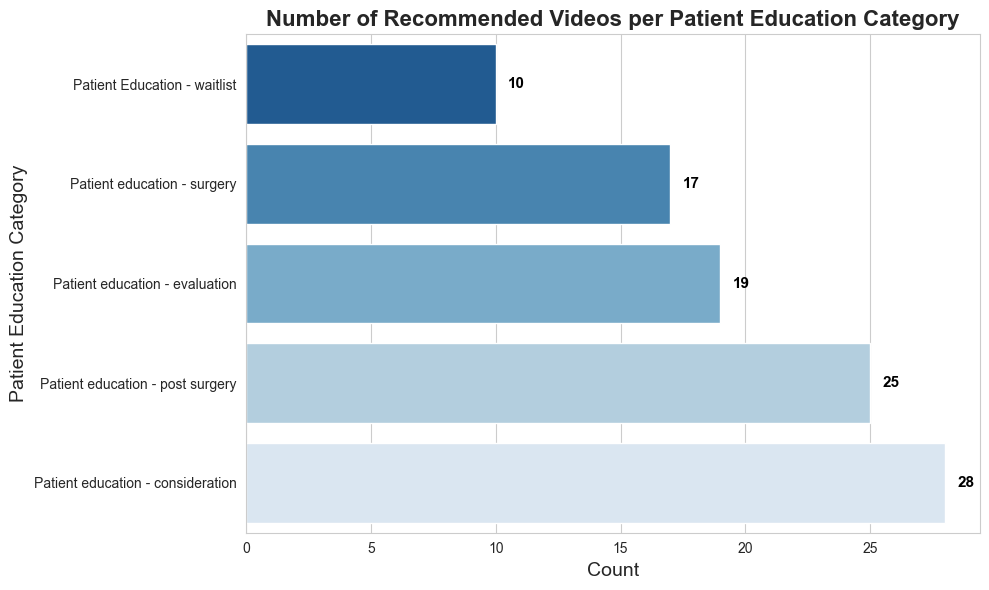

In [10]:
# ---------------------------------------------------
# Load top-K recommendations (if needed)
# ---------------------------------------------------
df_top = pd.read_csv(
    "integrated_features/data/youtube_recommendations_topK_dynamic.csv"
)

# ---------------------------------------------------
# Filter for Patient Education categories only
# ---------------------------------------------------
df_patient = df_top[df_top["Category_gpt_5"].str.startswith("Patient", na=False)].copy()

# Count per category and sort
cat_counts = df_patient["Category_gpt_5"].value_counts().sort_values(ascending=True)

# ---------------------------------------------------
# Fancy visualization styling
# ---------------------------------------------------
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Custom color palette (professional blue-gradient)
palette = sns.color_palette("Blues_r", n_colors=len(cat_counts))

# Horizontal barplot
ax = sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    palette=palette
)

# ---------------------------------------------------
# Add labels on bars
# ---------------------------------------------------
for i, v in enumerate(cat_counts.values):
    ax.text(
        v + 0.5,                      # x position
        i,                            # y position
        str(v),                       # label text
        color="black",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# ---------------------------------------------------
# Titles and labels
# ---------------------------------------------------
plt.title("Number of Recommended Videos per Patient Education Category", fontsize=16, fontweight="bold")
plt.xlabel("Count", fontsize=14)
plt.ylabel("Patient Education Category", fontsize=14)

plt.tight_layout()
plt.show()
